## Setup

In [ ]:
# create a virtual environment and then run this cell
!python.exe -m pip install --upgrade pip
!pip install -r requirements.txt

In [25]:
# imports
import numpy as np
import random
import networkx
import time
import matplotlib.pyplot as plt
from scipy.sparse import csr_array, diags
from scipy.linalg import eig
from scipy.optimize import linear_sum_assignment

## PageRank

In [26]:
# function to generate random 2D graph of any given size with uniform edge cost 1
def generate_random_2D_graph(M: int, density = 0.2) -> csr_array:

    rng = np.random.default_rng(seed = 13)
    G = rng.choice([0, 1], size = (M, M), p = [1 - density, density])
    #G = np.zeros((M,M))
    #for i in range(M):
    #   for j in range(M):
    #        if random.randint(0,1) == 1:
    #            G[i][j] = 1
    return csr_array(G)


In [27]:
# helper functions

# function to calculate ∑_k a[j][k]
def sum_for_M(A: csr_array, j: int) -> int:
    result = 0
    non_zeroes = A.nonzero()
    for i in range(len(non_zeroes[0])):
        if non_zeroes[0][i] == j:
            result += A[j, non_zeroes[1][i]]
            
    # for k in range(A.shape[0]):
    #     result += A[j][k]
    return result

# function to construct M from input matrix A
# mara (edit): miiiight be better this way
def construct_M(A: csr_array) -> csr_array:

    out_degrees = np.squeeze(np.asarray(A.sum(axis = 1)))
    
    if out_degrees.ndim == 0:
        out_degrees = np.atleast_1d(out_degrees)
    out_degrees[out_degrees == 0] = 1.0
    
    inv_degrees = diags(1.0 / out_degrees)

    return (inv_degrees @ A).transpose().tocsr()
    #M = np.zeros((A.shape[0], A.shape[1]))
    
    #for i in range(A.shape[0]):
    #    for j in range(A.shape[1]):
    #        local_sum = sum_for_M(A,j)
            # if local_sum is 0 then we don't want to divide by it
    #        if local_sum == 0:
    #            M[i][j] = 0
    #        else:
    #            M[i][j] = A[j,i]/sum_for_M(A,j)
    
    #return csr_array(M)

# function to calculate l1-norm of r_new - r_old for convergence
def l1_norm_1D(v1: np.array, v2: np.array) -> int:
    vector = v2-v1
    result = 0
    for value in vector:
        result += abs(value)
    return result

def subtract_vectors(v1: np.array, v2: np.array) -> np.array:
    result = np.zeros(v1.shape[0])
    for i in range(v1.shape[0]):
        result[i] = v2[i] - v1[i]
    return result

# calculates the sum of all values of a vector
def vector_sum(vector: np.array) -> int:
    result = 0
    for v in vector:
        result += v
    return result

# calculates outdeg of a vertex; 
def outdeg(G: csr_array, v: int) -> int:
    result = 0
    for u in G.nonzero()[0]:
        if u == v:
            result += 1
    return result

# calculates indeg of a vertex; 
def indeg(G: csr_array, v: int) -> int:
    result = 0
    for row in G:
        if row[v] > 0:
            result += 1
    return result

# creates a prettier output string for the resulting vector r of the PageRank algorithm
def vector_toString(vector: np.array) -> str:
    s = "[\n"
    for i in range(vector.shape[0]):
        s += f" Vertex {i}: {vector[i]}"
        if i < vector.shape[0]-1:
            s += ","
        s += "\n"
    s += "]\n"
    return s

# constructs the Google Matrix from the sparse matrix M
# mara (edit): more readable, does the same thing
def google_matrix(M: csr_array, beta: int) -> csr_array:
    if beta > 1 or beta < 0:
        raise Exception("Error: Invalid beta value. Must be between and including 0 and 1.")
    
    helper_matrix = np.empty((M.shape[0], M.shape[1]))
    helper_matrix[:] = 1/M.shape[0]
    
    return beta * M + (1 - beta) * helper_matrix

# checks if the given vertex of the graph is a dead-end (outdegree of vertex = 0)
def is_dead_end(G: csr_array, vertex: int) -> bool:
    if outdeg(G, vertex) == 0:
        return True
    return False

# function to turn NetworkX PageRank to NumPy for accuracy measures with our custom PageRank implementation
def pagerank_to_array(pagerank: dict) -> np.array:
    items = [pagerank[i] for i in list(pagerank.keys())]
    return np.array(items)
    

def print_accuracy_score(r: np.array, networkx_r: np.array) -> float:
    if len(r) != len(networkx_r):
        raise Exception("Input vectors must be of equal size.")
    
    networkx_r = pagerank_to_array(networkx_r)
    sum_accuracy = 0
    for i in range(len(r)):
        if r[i] <= networkx_r[i]:
            sum_accuracy += (r[i]/networkx_r[i])
        else:
            sum_accuracy += (networkx_r[i]/r[i])
    
    print(f"Custom implementation is {((sum_accuracy/len(r))*100):.2f}% accurate compared to NetworkX.")

# def initialize_transportation_matrix(G: csr_array, probability: float) -> np.array:
#     t = np.empty(G.shape, dtype=float)
#     t[:] = probability
#     return t

In [28]:
# important functions for PageRank

def power_iteration(M: csr_array, epsilon: float = 1e-6) -> np.array:
    n = M.shape[0]
    r_old = np.ones(n, dtype=float) / n
    while True:
        r_new = np.squeeze(np.asarray(M @ r_old))
        if l1_norm_1D(r_old, r_new) < epsilon:
            break
        r_old = r_new.copy()
    
    return r_new

def personalized_pagerank(G: csr_array, teleportation: np.array, epsilon: float = 1e-6, beta: float = 0.85) -> np.array:
    if beta > 1:
        raise Exception("Error: Beta parameter must not be above 1.")
    elif beta < 0:
        raise Exception("Error: Beta paramter must not be less than 0.")
    
    n = G.shape[0]
    
    #print("\nCurrent step: Constructing M\n")
    M = construct_M(G)
    r_new = np.zeros(n)
    #print("\nCurrent step: Initializing r\n")
    for i in range(n):
        r_new[i] = 1/n
    #print(f"Graph G: \n{G}\n\nMatrix M: \n{M}\n\nBeta: {beta}\nEpsilon: {epsilon}\n")

    iter = 0
    
    while(True):
        #print(f"\n    Iteration {iter+1} \n")
        #print(f"    \nIteration: {iter}\n\n{r_new.transpose()}\n")
        
        r_old = r_new.copy()
        
        r_new_hat = (beta*M) @ r_new
        
        D = vector_sum(r_new_hat)
        for v in range(n):
            r_new[v] = (r_new_hat[v] + (teleportation[v]*(1-D)))
        
        if l1_norm_1D(r_old, r_new) < epsilon:
            #print(f"PageRank algorithm converged. Stopping now.\n")
            break
        
        iter += 1
        
    print(f"Finished in {iter} iterations.")

    return r_new

def google_pagerank(G: csr_array, epsilon: float = 1e-6, beta: float = 0.85) -> np.array:
    M = construct_M(G)
    G_M = google_matrix(M, beta=beta)
    
    return power_iteration(G_M, epsilon = epsilon)

def pagerank(G: csr_array, teleportation: np.array, epsilon: float = 1e-6, beta: float = 0.85) -> np.array:
    # check for dead-ends
    for i in range(G.shape[0]):
        if is_dead_end(G,i):
            #print(f"Dead-end found. Using general PageRank.")
            return personalized_pagerank(G, teleportation = teleportation, epsilon = epsilon, beta = beta)
    
    #print("No dead-ends found. Using Google PageRank.")
    return google_pagerank(G, epsilon = epsilon, beta = beta)

In [29]:
# test functions

def test_custom_pagerank(G: csr_array, teleportation: np.array, epsilon: float = 1e-6, beta: float = 0.85):
    start = time.time()
    r1 = pagerank(G, teleportation=teleportation, epsilon=epsilon, beta=beta)
    end = time.time()
    custom_time = end - start
    
    start = time.time()
    # use digraph to get 100% or just graph for 72% acc
    r2 = networkx.pagerank(networkx.DiGraph(G))
    end = time.time()
    networkx_time = end - start
    
    print(f"Got PageRank vector: \n{vector_toString(r1)}\n in {custom_time:.5f} seconds.\n")
    print(f"Got NetworkX PageRank vector: \n{vector_toString(pagerank_to_array(r2))}\n in {networkx_time:.5f} seconds.\n")
    print_accuracy_score(r1,r2)

In [30]:
# Testing PageRank on lecture example

# lecture example graph as sparse matrix
A = csr_array(np.array([[0,1,0,0,0], [1,0,1,0,0], [0,0,0,1,1], [0,0,0,0,0], [0,1,0,0,0]]))
t = np.array([1/A.shape[0] for x in range(A.shape[0])])

test_custom_pagerank(A, teleportation=t)

Finished in 14 iterations.
Got PageRank vector: 
[
 Vertex 0: 0.1958069857355091,
 Vertex 1: 0.3355714833684033,
 Vertex 2: 0.1958069857355091,
 Vertex 3: 0.13640727258028928,
 Vertex 4: 0.13640727258028928
]

 in 0.00191 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.1958071483019602,
 Vertex 1: 0.33557117925541863,
 Vertex 2: 0.1958071483019602,
 Vertex 3: 0.13640726207033058,
 Vertex 4: 0.13640726207033058
]

 in 0.00123 seconds.

Custom implementation is 100.00% accurate compared to NetworkX.


In [33]:
# Testing PageRank on a few random graphs with teleportation 1/n

for i in range(5):
    print(f"Test: {i+1}\n")
    G = generate_random_2D_graph(random.randint(2,50))
    t = np.array([1/G.shape[0] for x in range(G.shape[0])])
    test_custom_pagerank(G, teleportation=t)
    print("\n")

Test: 1

Got PageRank vector: 
[
 Vertex 0: 0.02532263074581878,
 Vertex 1: 0.02341328038269129,
 Vertex 2: 0.0310401722081676,
 Vertex 3: 0.03748618011051019,
 Vertex 4: 0.02175677626206083,
 Vertex 5: 0.02660886489065417,
 Vertex 6: 0.0064995210356238444,
 Vertex 7: 0.01815824608465182,
 Vertex 8: 0.022718418795008813,
 Vertex 9: 0.026293174449119522,
 Vertex 10: 0.025692690937167733,
 Vertex 11: 0.025091255444787658,
 Vertex 12: 0.043531422320292994,
 Vertex 13: 0.014533747174451998,
 Vertex 14: 0.05249089983424791,
 Vertex 15: 0.04750792183454872,
 Vertex 16: 0.019964027239780753,
 Vertex 17: 0.027012810993831335,
 Vertex 18: 0.04073734078109477,
 Vertex 19: 0.018907455021732855,
 Vertex 20: 0.03319050382157332,
 Vertex 21: 0.0219143140672753,
 Vertex 22: 0.014532031735789243,
 Vertex 23: 0.017222574229435628,
 Vertex 24: 0.04365701777966896,
 Vertex 25: 0.0307488859930411,
 Vertex 26: 0.02702442227627054,
 Vertex 27: 0.04924318538288081,
 Vertex 28: 0.040007702519327004,
 Vertex 2

In [34]:
# generate a random graph and test out some different beta values but keep teleportation at 1/n

G = generate_random_2D_graph(50)

beta = 0.2
while(beta < 0.9):
    print(f"\n   Test with beta = {beta:.2f}\n")
    test_custom_pagerank(G,teleportation = 1/50, beta = beta)
    beta += 0.05


   Test with beta = 0.20

Got PageRank vector: 
[
 Vertex 0: 0.022044833584951386,
 Vertex 1: 0.020428340155521797,
 Vertex 2: 0.01751352288546302,
 Vertex 3: 0.020065667927757623,
 Vertex 4: 0.023391801288079512,
 Vertex 5: 0.018999144027485978,
 Vertex 6: 0.01734234197007508,
 Vertex 7: 0.019797197173291824,
 Vertex 8: 0.019865810387510518,
 Vertex 9: 0.01992134285151404,
 Vertex 10: 0.018173671166413233,
 Vertex 11: 0.019084224595731263,
 Vertex 12: 0.020113818794854996,
 Vertex 13: 0.018820643849593026,
 Vertex 14: 0.022254318653273604,
 Vertex 15: 0.02104458535253964,
 Vertex 16: 0.020234467970729114,
 Vertex 17: 0.0233240920091101,
 Vertex 18: 0.020207147211460524,
 Vertex 19: 0.02001704189062403,
 Vertex 20: 0.020259764407396817,
 Vertex 21: 0.022958960742165135,
 Vertex 22: 0.019046095645827297,
 Vertex 23: 0.01881921727876841,
 Vertex 24: 0.0187389065577608,
 Vertex 25: 0.019244507181807993,
 Vertex 26: 0.017736543151781213,
 Vertex 27: 0.023286005036503417,
 Vertex 28: 0.019

## Network Alignment

In [51]:
# get graphs
G = networkx.read_gml("./pa3_data/G.gml", label=None)
H = networkx.read_gml("./pa3_data/H.gml", label=None)

# get adjacency matrices of the graphs
G_A = networkx.adjacency_matrix(G=G)
H_A = networkx.adjacency_matrix(G=H)

# get Kronecker Product of both matrices
K = np.kron(G_A, H_A)
# load similarities
s = np.loadtxt("./pa3_data/sim.txt", delimiter=',')

# normalize s
s = s/s.shape[0]
s = csr_array(s)

In [52]:
# IsoRank helper functions

# computes L1 norm of r_old and r_new for error tolerance checking
def l1_norm_2D(a1: np.array, a2: np.array) -> int:
    vector = a2-a1
    result = 0
    for row in vector:
        for col in row:
            result += abs(col)
    return result

# Personalized PageRank adjusted for Network Alignment to handle its adjacency matrix and similarity matrix
def networt_alignment_pagerank(K: csr_array, s: csr_array, beta: float = 0.85, epsilon: float = 1e-6):
    if beta > 1:
        raise Exception("Error: Beta parameter must not be above 1.")
    elif beta < 0:
        raise Exception("Error: Beta paramter must not be less than 0.")

    n = K.shape[0]*K.shape[1]
    
    #print("\n=== Current step: Constructing M ===\n")
    M = construct_M(K)
    
    r_new = np.empty(K.shape, dtype=float)
    r_new[:] = 1/n

    iter = 0
    
    while(True):
        #print(f"\n  Iteration {iter+1} ===\n")
        #print(f"  \n\nIteration: {iter}\n\n{r_new.transpose()}\n\n")
        
        r_old = r_new.copy()
        
        r_new_hat = (beta*M) @ r_new
        
        D = np.sum(r_new_hat)
        for g in range(r_new_hat.shape[0]):
            for h in range(r_new_hat.shape[1]):
                r_new[g][h] = (r_new_hat[g][h] + (s[g][h]*(1-D)))

        
        if l1_norm_2D(r_old, r_new) < epsilon:
            #print(f"PageRank algorithm converged. Stopping now.\n")
            break
        
        iter += 1
    print(f"Finished in {iter} iterations.")
    return r_new



In [53]:
# IsoRank implementation
def isoRank(K: csr_array, s: csr_array, beta: float = 0.85, epsilon: float = 1e-6):
    t = networt_alignment_pagerank(K=K, s=s, beta=beta, epsilon=epsilon)
    matching = linear_sum_assignment(cost_matrix=t, maximize=True)
    return matching

In [54]:
# get Assignment similarities t with PageRank on K with s as teleportation and beta = 0.85

# t = pagerank(K, teleportation=s, beta=0.85)
# t = networt_alignment_pagerank(K=K, s=s)


In [55]:
#matching = isoRank(K=K,s=s)

In [56]:
#print(matching[0])
#print(matching[1])

In [57]:
# for u, v, weight in G.edges.data("weight"):
#     print(f"u: {u}, v: {v}")


In [58]:
# tried implementing the preserve edge count function to this understanding:
# - matching matches vertex of G at index i in matching[0] to vertex of H at index i in matching[1]
# - example: matching[0][0] = 0 and matching[1][0] = 10 -> vertex 0 of G is matched to vertex 10 of H
# - so this function then checkes if an edge between the mapped vertices exist in H
# feel free to correct this (and any other function) if I misunderstood the assignment :)

def count_preserved_edges(G: networkx.classes.graph.Graph, H: networkx.classes.graph.Graph, matching: tuple) -> int:
    col = matching[1]
    count = 0
    # since matching[0] already has the vertices of G in the right position (simply ordered numerically ascending; vertex number equals index in array)
    # the vertices are not checked further
    for u, v, _ in G.edges.data():
        if H.has_edge(col[u], col[v]):
            count += 1
    
    return count

In [59]:
#print(count_preserved_edges(G=G, H=H, matching=matching))

## Testing Task 3-2

In [ ]:

beta_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

print("Isorank for different betas:")

for b in beta_values:

    matching = isoRank(K = K, s = s, beta = b)
    
    preserved_count = count_preserved_edges(G, H, matching)
    results.append((b, preserved_count))

    print(f"Beta: {b:.1f} | Preserved Edges: {preserved_count}")

Isorank for different betas:
Finished in 1 iterations.
Beta: 0.0 | Preserved Edges: 84
Finished in 6 iterations.
Beta: 0.1 | Preserved Edges: 84
Finished in 9 iterations.
Beta: 0.2 | Preserved Edges: 81
Finished in 12 iterations.
Beta: 0.3 | Preserved Edges: 81
Finished in 15 iterations.
Beta: 0.4 | Preserved Edges: 79
Finished in 20 iterations.
Beta: 0.5 | Preserved Edges: 76
Finished in 27 iterations.
Beta: 0.6 | Preserved Edges: 49
Finished in 39 iterations.
Beta: 0.7 | Preserved Edges: 47
Finished in 61 iterations.
Beta: 0.8 | Preserved Edges: 49
Finished in 129 iterations.
Beta: 0.9 | Preserved Edges: 49


## Testing Task 3-1

In [44]:
# Check if your code computes the same PageRank values obtained for the example presented in the
# lecture. To this end, choose the teleportation probability t(v) = 1 /n for all vertices v, where nis the
# number of vertices.

# lecture example graph as sparse matrix
A = csr_array(np.array([[0,1,0,0,0], [1,0,1,0,0], [0,0,0,1,1], [0,0,0,0,0], [0,1,0,0,0]]))
t = np.array([1/A.shape[0] for x in range(A.shape[0])])

test_custom_pagerank(A, teleportation=t)

Finished in 14 iterations.
Got PageRank vector: 
[
 Vertex 0: 0.1958069857355091,
 Vertex 1: 0.3355714833684033,
 Vertex 2: 0.1958069857355091,
 Vertex 3: 0.13640727258028928,
 Vertex 4: 0.13640727258028928
]

 in 0.00141 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.1958071483019602,
 Vertex 1: 0.33557117925541863,
 Vertex 2: 0.1958071483019602,
 Vertex 3: 0.13640726207033058,
 Vertex 4: 0.13640726207033058
]

 in 0.00117 seconds.

Custom implementation is 100.00% accurate compared to NetworkX.


  Graph size = 10
Got PageRank vector: 
[
 Vertex 0: 0.034114628957577275,
 Vertex 1: 0.04760180784778225,
 Vertex 2: 0.033604054561381554,
 Vertex 3: 0.03432715149364855,
 Vertex 4: 0.3377431694466614,
 Vertex 5: 0.033604054561381554,
 Vertex 6: 0.015000000000000003,
 Vertex 7: 0.0596993939019978,
 Vertex 8: 0.06821347585993577,
 Vertex 9: 0.3360922633696337
]

 in 0.00084 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.03411462895757728,
 Vertex 1: 0.04760180784778226,
 Vertex 2: 0.03360405456138156,
 Vertex 3: 0.03432715149382458,
 Vertex 4: 0.33774512884633545,
 Vertex 5: 0.03360405456138156,
 Vertex 6: 0.015000000000000003,
 Vertex 7: 0.05969939390255863,
 Vertex 8: 0.06821347586032057,
 Vertex 9: 0.33609030396883816
]

 in 0.00130 seconds.

Custom implementation is 100.00% accurate compared to NetworkX.
  Graph size = 20
Got PageRank vector: 
[
 Vertex 0: 0.044094962554616465,
 Vertex 1: 0.0329224802985859,
 Vertex 2: 0.02822286226518832,
 Vertex 3: 0.032166765878660845,


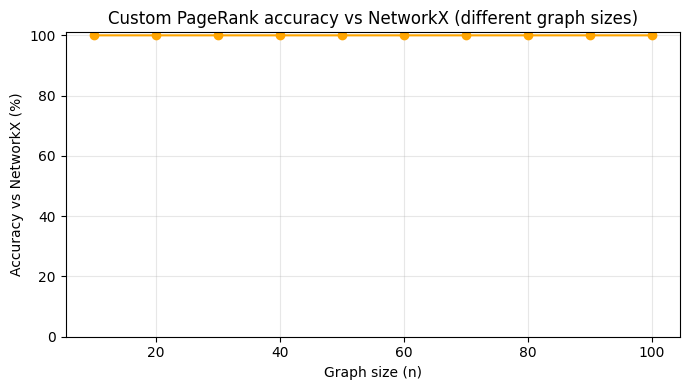

In [45]:
# networkx on random graphs

sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracies = []

for n in sizes:
    print(f"  Graph size = {n}")
    G = generate_random_2D_graph(n)
    t = np.ones(n) / n
    test_custom_pagerank(G, teleportation = t)
 
    # collect accuracy for plot
    r1 = pagerank(G, teleportation = t)
    r2 = networkx.pagerank(networkx.DiGraph(G))
    r2_arr = pagerank_to_array(r2)
    acc = sum(
        r1[i] / r2_arr[i] if r1[i] <= r2_arr[i] else r2_arr[i] / r1[i]
            for i in range(n)
    ) / n * 100
    accuracies.append(acc)

plt.figure(figsize=(7, 4))
plt.plot(sizes, accuracies, "o-", color="orange")
plt.xlabel("Graph size (n)")
plt.ylabel("Accuracy vs NetworkX (%)")
plt.title("Custom PageRank accuracy vs NetworkX (different graph sizes)")
plt.ylim(0, 101)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()


  Test with beta = 0.10

Got PageRank vector: 
[
 Vertex 0: 0.09650190136531214,
 Vertex 1: 0.0998295534357854,
 Vertex 2: 0.09787072260588141,
 Vertex 3: 0.09343720455675589,
 Vertex 4: 0.1109697639317559,
 Vertex 5: 0.09787072260588141,
 Vertex 6: 0.09000000000000005,
 Vertex 7: 0.09835495278849458,
 Vertex 8: 0.10311612290809336,
 Vertex 9: 0.11204905580204053
]

 in 0.00046 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.03411462895757728,
 Vertex 1: 0.04760180784778226,
 Vertex 2: 0.03360405456138156,
 Vertex 3: 0.03432715149382458,
 Vertex 4: 0.33774512884633545,
 Vertex 5: 0.03360405456138156,
 Vertex 6: 0.015000000000000003,
 Vertex 7: 0.05969939390255863,
 Vertex 8: 0.06821347586032057,
 Vertex 9: 0.33609030396883816
]

 in 0.00157 seconds.

Custom implementation is 39.82% accurate compared to NetworkX.

  Test with beta = 0.20

Got PageRank vector: 
[
 Vertex 0: 0.09255871483234275,
 Vertex 1: 0.09917005212543832,
 Vertex 2: 0.09473424008626746,
 Vertex 3: 0.08704559

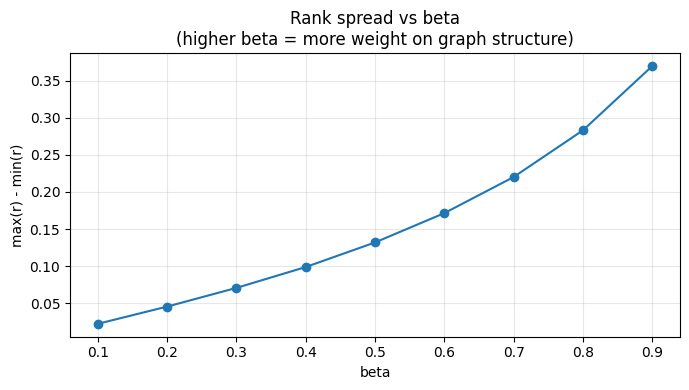

In [46]:
# "Test different parameters for β and teleportation probabilities. Are the results as expected?"

# beta sweep
G = generate_random_2D_graph(10)
n = G.shape[0]
 
betas = []
spreads = []   # max(r) - min(r): how different are ranks
 
beta = 0.1
while beta < 1.0:

    t = np.ones(n) / n
    print(f"\n  Test with beta = {beta:.2f}\n")

    test_custom_pagerank(G, teleportation = t, beta = beta)
 
    r = pagerank(G, teleportation = t, beta = beta)

    betas.append(beta)
    spreads.append(float(r.max() - r.min()))
 
    beta = round(beta + 0.1, 2)
 

plt.figure(figsize=(7, 4))
plt.plot(betas, spreads, "o-")
plt.xlabel("beta")
plt.ylabel("max(r) - min(r)")
plt.title("Rank spread vs beta\n(higher beta = more weight on graph structure)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Uniform teleportation:

Finished in 12 iterations.
Got PageRank vector: 
[
 Vertex 0: 0.30303021943326336,
 Vertex 1: 0.30303021943326336,
 Vertex 2: 0.30303021943326336,
 Vertex 3: 0.045454670850105044,
 Vertex 4: 0.045454670850105044
]

 in 0.00129 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.30303005715665693,
 Vertex 1: 0.30303005715665693,
 Vertex 2: 0.30303005715665693,
 Vertex 3: 0.04545491426501476,
 Vertex 4: 0.04545491426501476
]

 in 0.00072 seconds.

Custom implementation is 100.00% accurate compared to NetworkX.

Biased teleportation (all on vertex 3):

Finished in 75 iterations.
Got PageRank vector: 
[
 Vertex 0: 8.64705756080646e-07,
 Vertex 1: 8.64705756080646e-07,
 Vertex 2: 8.64705756080646e-07,
 Vertex 3: 0.9999974058827318,
 Vertex 4: 0.0
]

 in 0.00214 seconds.

Got NetworkX PageRank vector: 
[
 Vertex 0: 0.30303005715665693,
 Vertex 1: 0.30303005715665693,
 Vertex 2: 0.30303005715665693,
 Vertex 3: 0.04545491426501476,
 Vertex 4: 0.04545491426501476
]


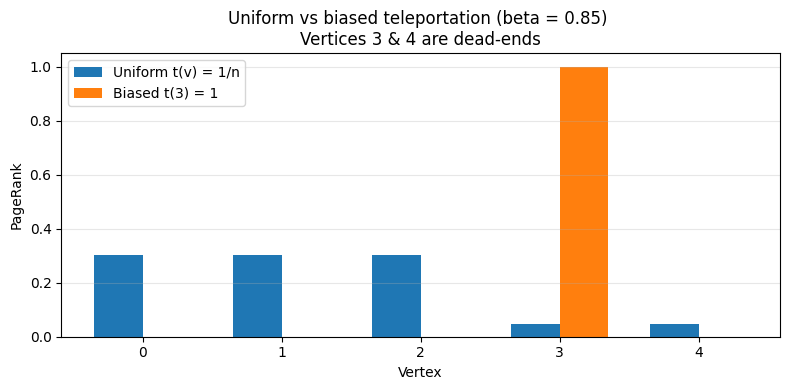

In [47]:
G_test = csr_array(np.array([
    [0, 1, 0, 0, 0],  # 0 - 1
    [0, 0, 1, 0, 0],  # 1 - 2
    [1, 0, 0, 0, 0],  # 2 - 0
    [0, 0, 0, 0, 0],  # 3  (deadend)
    [0, 0, 0, 0, 0],  # 4  (deadend)
], dtype=float))
n = G_test.shape[0]
 
t_uniform = np.ones(n) / n
 
# all teleportation to 3
t_biased = np.zeros(n)
t_biased[3] = 1.0
 
print("\nUniform teleportation:\n")
test_custom_pagerank(G_test, teleportation = t_uniform, beta = 0.85)
 
print("\nBiased teleportation (all on vertex 3):\n")
test_custom_pagerank(G_test, teleportation = t_biased, beta = 0.85)
 
r_uniform = pagerank(G_test, teleportation = t_uniform, beta = 0.85)
r_biased  = pagerank(G_test, teleportation = t_biased,  beta = 0.85)
 
x = np.arange(n)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, r_uniform, width, label="Uniform t(v) = 1/n")
ax.bar(x + width/2, r_biased,  width, label="Biased t(3) = 1")
ax.set_xlabel("Vertex")
ax.set_ylabel("PageRank")
ax.set_title("Uniform vs biased teleportation (beta = 0.85) \nVertices 3 & 4 are dead-ends")
ax.set_xticks(x)
ax.legend()
ax.grid(axis = "y", alpha = 0.3)
plt.tight_layout()
plt.show()

In [48]:
n = 6
A = np.ones((n, n)) - np.eye(n)
G_nodead = csr_array(A)

t = np.ones(n) / n
beta = 0.85

r_pers = personalized_pagerank(G_nodead, teleportation=t, beta=beta)
r_google = google_pagerank(G_nodead, beta=beta)

M = construct_M(G_nodead)
Gm = google_matrix(M, beta)
vals, vecs = eig(Gm)
dominant_idx = np.argmax(np.real(vals))
r_eig = np.abs(np.real(vecs[:, dominant_idx]))
r_eig = r_eig / r_eig.sum() 

print("\nVertex | Pers. PR   | Google PR  | Eigenvector")

for i in range(n):
    print(f"  {i}    | {r_pers[i]:.8f} | {r_google[i]:.8f} | {r_eig[i]:.8f}")

print(f"\nL1 diff (pers vs google) : {l1_norm_1D(r_pers, r_google):.2e}")
print(f"L1 diff (google vs eig)  : {l1_norm_1D(r_google, r_eig):.2e}")

Finished in 0 iterations.

Vertex | Pers. PR   | Google PR  | Eigenvector
  0    | 0.16666667 | 0.16666667 | 0.16666667
  1    | 0.16666667 | 0.16666667 | 0.16666667
  2    | 0.16666667 | 0.16666667 | 0.16666667
  3    | 0.16666667 | 0.16666667 | 0.16666667
  4    | 0.16666667 | 0.16666667 | 0.16666667
  5    | 0.16666667 | 0.16666667 | 0.16666667

L1 diff (pers vs google) : 0.00e+00
L1 diff (google vs eig)  : 1.39e-16


Finished in 7 iterations.
Finished in 6 iterations.
Finished in 4 iterations.
Finished in 3 iterations.
Finished in 3 iterations.


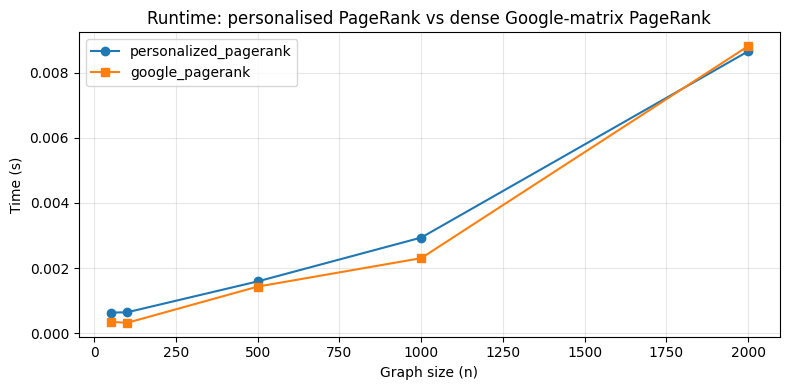

In [49]:
sizes = [50, 100, 500, 1000, 2000]
times_pers  = []
times_dense = []
 
for size in sizes:
    G_scale = generate_random_2D_graph(size)
    t_scale = np.ones(size) / size
 
    start = time.time()
    personalized_pagerank(G_scale, teleportation=t_scale, epsilon=1e-5)
    t_sparse = time.time() - start
 
    start = time.time()
    google_pagerank(G_scale, epsilon=1e-5)
    t_dense = time.time() - start
 
    times_pers.append(t_sparse)
    times_dense.append(t_dense)

 
plt.figure(figsize=(8, 4))
plt.plot(sizes, times_pers,  "o-", label = "personalized_pagerank")
plt.plot(sizes, times_dense, "s-", label = "google_pagerank")
plt.xlabel("Graph size (n)")
plt.ylabel("Time (s)")
plt.title("Runtime: personalised PageRank vs dense Google-matrix PageRank")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()